In [15]:
import torch
import numpy as np

a = torch.tensor([1.0, 2.0, 3.0])          # from list
b = torch.zeros(3, 4)                       # zeros: shape (3,4)
c = torch.ones(2, 3)                        # ones: shape (2,3)
d = torch.rand(3, 3)                        # random uniform 0-1
e = torch.randn(3, 3)                       # random normal mean=0 std=1
f = torch.arange(0, 10, 2)                  # [0, 2, 4, 6, 8]
g = torch.linspace(0, 1, 5)                 # [0, 0.25, 0.5, 0.75, 1.0]

print(f"tensor:  {a}")
print(f"zeros:   {b.shape}")
print(f"ones:    {c}")
print(f"rand:    {d}")
print(f"arange:  {f}")
print(f"linspace:{g}")

x_float32 = torch.tensor([1.0, 2.0], dtype=torch.float32)
x_float64 = torch.tensor([1.0, 2.0], dtype=torch.float64)
x_int      = torch.tensor([1, 2, 3],  dtype=torch.long) 
x_bool     = torch.tensor([True, False, True])

print(f"\nfloat32 dtype: {x_float32.dtype}")
print(f"int dtype:     {x_int.dtype}")

t = torch.rand(4, 3)
print(f"\nOriginal shape: {t, t.shape}")                           # (4, 3)
print(f"Transposed:     {t.T, t.T.shape}")                         # (3, 4)
print(f"Reshaped:       {t.reshape(2,6), t.reshape(2,6).shape}")   # (2, 6)
print(f"Unsqueezed:     {t.unsqueeze(0).shape}")      # (1, 4, 3) ← adds dimension
print(f"Squeezed:       {t.unsqueeze(0).squeeze(0).shape}")

tensor:  tensor([1., 2., 3.])
zeros:   torch.Size([3, 4])
ones:    tensor([[1., 1., 1.],
        [1., 1., 1.]])
rand:    tensor([[0.8662, 0.0992, 0.5108],
        [0.7199, 0.3103, 0.5044],
        [0.2992, 0.5060, 0.3104]])
arange:  tensor([0, 2, 4, 6, 8])
linspace:tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])

float32 dtype: torch.float32
int dtype:     torch.int64

Original shape: (tensor([[0.4741, 0.0780, 0.7419],
        [0.4768, 0.9226, 0.0612],
        [0.0080, 0.0242, 0.7750],
        [0.3346, 0.7163, 0.4936]]), torch.Size([4, 3]))
Transposed:     (tensor([[0.4741, 0.4768, 0.0080, 0.3346],
        [0.0780, 0.9226, 0.0242, 0.7163],
        [0.7419, 0.0612, 0.7750, 0.4936]]), torch.Size([3, 4]))
Reshaped:       (tensor([[0.4741, 0.0780, 0.7419, 0.4768, 0.9226, 0.0612],
        [0.0080, 0.0242, 0.7750, 0.3346, 0.7163, 0.4936]]), torch.Size([2, 6]))
Unsqueezed:     torch.Size([1, 4, 3])
Squeezed:       torch.Size([4, 3])


In [18]:
a = torch.tensor([[1.0, 2.0], 
                  [3.0, 4.0]])
b = torch.tensor([[5.0, 6.0],
                  [7.0, 8.0]])

print("Element-wise add:     \n", a + b)
print("Element-wise multiply:\n", a * b)                    # NOT matrix multiply
print("Matrix multiply:      \n", a @ b)                    # THIS is matrix multiply
print("Matrix multiply:      \n", torch.matmul(a, b))       # same thing

t = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

print(f"\nSum all:     {t.sum()}")
print(f"Sum cols:      {t.sum(dim=0)}")    # sum down rows → (3,)
print(f"Sum rows:      {t.sum(dim=1)}")    # sum across cols → (2,)
print(f"Mean:          {t.mean()}")
print(f"Max value:     {t.max()}")
print(f"Max per row:   {t.max(dim=1)}")    # returns values AND indices

x = torch.tensor([1.0, 5.0, 3.0, 8.0, 2.0])
mask = x > 3
print(f"\nMask (x>3):    {mask}")
print(f"Filtered:      {x[mask]}")          # [5.0, 8.0]

Element-wise add:     
 tensor([[ 6.,  8.],
        [10., 12.]])
Element-wise multiply:
 tensor([[ 5., 12.],
        [21., 32.]])
Matrix multiply:      
 tensor([[19., 22.],
        [43., 50.]])
Matrix multiply:      
 tensor([[19., 22.],
        [43., 50.]])

Sum all:     21.0
Sum cols:      tensor([5., 7., 9.])
Sum rows:      tensor([ 6., 15.])
Mean:          3.5
Max value:     6.0
Max per row:   torch.return_types.max(
values=tensor([3., 6.]),
indices=tensor([2, 2]))

Mask (x>3):    tensor([False,  True, False,  True, False])
Filtered:      tensor([5., 8.])


In [ ]:
x = torch.tensor(3.0, requires_grad=True)
y = torch.tensor(4.0, requires_grad=True)

# Build a computation
z = x**2 + 2*y + 1   # z = x² + 2y + 1

print(f"x = {x}")
print(f"y = {y}")
print(f"z = {z}")

# Compute gradients
z.backward()

print(f"\ndz/dx = {x.grad}")   # should be 2x = 2*3 = 6
print(f"dz/dy = {y.grad}")     # should be 2

# ── Multiple operations ────────────────────────────────────────
a = torch.tensor(2.0, requires_grad=True)

b = a * 3        # b = 3a
c = b ** 2       # c = b² = (3a)² = 9a²
d = c + 10       # d = 9a² + 10

d.backward()

print(f"\na = {a.item()}")
print(f"d = {d.item()}")
print(f"dd/da = {a.grad.item()}")   # should be 18a = 18*2 = 36
# Manually: dd/da = 18a = 36 

x = 3.0
y = 4.0
z = 18.0

dz/dx = 6.0
dz/dy = 2.0

a = 2.0
d = 46.0
dd/da = 36.0


In [ ]:
x = torch.tensor(2.0, requires_grad=True)

for i in range(3):
    y = x ** 2
    y.backward()
    print(f"After backward {i+1}: x.grad = {x.grad}")
    # also paste x.grad.zero_() here and see the output
    # Watch it accumulate: 4, 8, 12 — NOT 4, 4, 4!

# Reset:
x.grad.zero_()
print(f"After zero_(): x.grad = {x.grad}")  # back to 0

After backward 1: x.grad = 4.0
After backward 2: x.grad = 8.0
After backward 3: x.grad = 12.0
After zero_(): x.grad = 0.0


In [23]:
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)

# WITHOUT no_grad — PyTorch tracks everything
y = (x ** 2).sum()
print(f"y.requires_grad: {y.requires_grad}")   # True

# WITH no_grad — PyTorch stops tracking
with torch.no_grad():
    y_no_grad = (x ** 2).sum()
    print(f"y_no_grad.requires_grad: {y_no_grad.requires_grad}")  # False

# This is why model.eval() + torch.no_grad() go together during testing
# model.eval()     → disables dropout/batchnorm training behaviour
# torch.no_grad()  → disables gradient computation
# BOTH are needed for proper inference

y.requires_grad: True
y_no_grad.requires_grad: False


In [24]:
import numpy as np

# NumPy → PyTorch
np_array = np.array([1.0, 2.0, 3.0])
tensor   = torch.from_numpy(np_array)
print(f"NumPy → Tensor: {tensor}")

# PyTorch → NumPy
tensor2   = torch.tensor([4.0, 5.0, 6.0])
np_back   = tensor2.numpy()
print(f"Tensor → NumPy: {np_back}")

# GPU tensor → NumPy (need .cpu() first)
# np_from_gpu = gpu_tensor.cpu().numpy()

# Getting a plain Python number from a tensor
t = torch.tensor(42.0)
print(f"Python float: {t.item()}")   # .item() → plain Python number

# This is why you see .item() everywhere when printing losses:
# loss.item() converts 1-element tensor to readable Python float

NumPy → Tensor: tensor([1., 2., 3.], dtype=torch.float64)
Tensor → NumPy: [4. 5. 6.]
Python float: 42.0


Learned weight: 2.9941 (true: 3.0)
Learned bias:   2.0120 (true: 2.0)


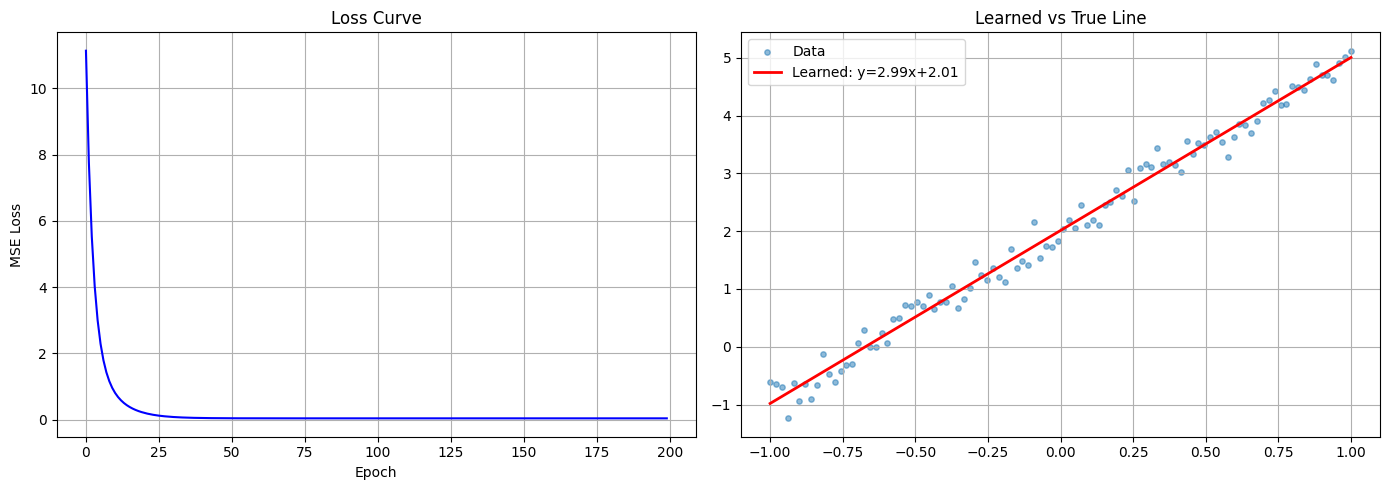

In [26]:
import torch 
import torch.nn as nn
import matplotlib.pyplot as plt

# Data: y = 3x + 2 (we want model to learn slope=3, intercept=2)

torch.manual_seed(42)
X = torch.linspace(-1,1,100).unsqueeze(1) 
y = 3 * X + 2 + 0.2 * torch.randn_like(X) 

model = nn.Linear(1,1)
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1) 

losses = []

for epoch in range(200):
    model.train()
    prediction = model(X)
    loss = criterion(prediction, y)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

weight = model.weight.item()
bias   = model.bias.item()
print(f"Learned weight: {weight:.4f} (true: 3.0)")
print(f"Learned bias:   {bias:.4f} (true: 2.0)")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(losses, 'b-', linewidth=1.5)
ax1.set_title("Loss Curve")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE Loss")
ax1.grid(True)

ax2.scatter(X.numpy(), y.numpy(), alpha=0.5, label='Data', s=15)
ax2.plot(X.numpy(), model(X).detach().numpy(),
         'r-', linewidth=2, label=f'Learned: y={weight:.2f}x+{bias:.2f}')
ax2.set_title("Learned vs True Line")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()